# Synthetischer Datensatz — Drift-Erkennung

Wendet die vier Drift-Detektoren KSWIN, ADWIN, DDM und EDDM (`drift_detection.py`) auf den normierten Prädiktionsfehler des drift-behafteten Stroms an; Tuning und Kennzahlen über das gesamte Jahr (4 Sudden Drifts).

In [1]:
FORCE_RECOMPUTE = False
IS_FINAL = True

In [2]:
# --- Konstanten ---
RUN_ID = "e7f8df2f"   # None -> neuestes Modell

SEED = 42

DETECTORS = ("KSWIN", "ADWIN", "DDM", "EDDM", "RMSE")
N_TRIALS  = {
    "KSWIN": 40,
    "ADWIN": 40,
    "RMSE": 40,
    "DDM": 200,
    "EDDM": 200,
}
# 500 Trials fuer DDM/EDDM haben am 2026-09-02 nichts gebracht: TPE zieht
# unabhaengig davon nur n_startup_trials = 10 Zufallspunkte, und die ersten
# 200 Trials sind bei gleichem Seed ohnehin identisch. Wieder bei 200.
DOWNSAMPLE = 5           # Tuning nur auf jedem q-ten Punkt

# Gewichte der Tuning-Zielfunktion: (Recall, Verzug, Praezision). Alle drei
# Terme liegen in [0, 1], die Gewichte sind also direkt vergleichbar. Recall
# wiegt doppelt so schwer wie Praezision -- ein verpasstes Ereignis ist teurer
# als ein Fehlalarm, aber nicht beliebig viel teurer. Frueher stand hier
# (3.0, 0.3, 0.05) auf einem unbeschraenkten Fehlalarm-Term, der nur auf dem
# stabilen Sechstel des Stroms gemessen wurde; damit gewann Dauerfeuer.
WEIGHTS = (3.0, 0.3, 1.5)
# Der Fehlalarm-Term ist log10(1 + Fehlalarme je Ereignis) / FA_DECADES, gekappt
# bei 1: 0 = kein Fehlalarm, 1 = 1000 Fehlalarme je Ereignis. Logarithmisch,
# weil die Kandidaten sich ueber Groessenordnungen unterscheiden -- ein linearer
# Term aus (1 - precision) liegt dort fuer alle bei 0,98 bis 0,99 und traegt
# keinen Gradienten; das Tuning optimiert dann nur den Verzug und senkt ihn,
# indem es haeufiger feuert.
FA_DECADES = 3.0

# Kandidaten je Detektor, die nach dem Tuning auf dem VOLLEN Raster gegengeprueft
# werden. Das Tuning laeuft auf jedem DOWNSAMPLE-ten Punkt, und die Rangfolge
# dort stimmt nicht zwingend: im Lauf b4002952 war DDM auf dem Eval-Raster
# erster und auf dem vollen Strom dritter.
TOP_K = 5

# Toleranz und Cooldown relativ statt als feste Schrittzahl: als Schrittzahl
# bedeuten sie in den beiden Stroemen Verschiedenes (der synthetische Strom
# tastet je Minute ab, der TEP je 3 Minuten, und die Ereignisabstaende
# unterscheiden sich um Faktor 3). Die Toleranz ist ein Anteil des mittleren
# Ereignisabstands, der Cooldown ein Anteil der Stromlaenge. Gerundet wird auf
# QUANT Schritte, damit eine geringfuegig andere Ereignislage den Cache nicht
# neu schluesselt.
TOLERANCE_REL = 0.0092   # Anteil des mittleren Ereignisabstands -> TOLERANCE
COOLDOWN_REL  = 0.0095   # Anteil der Stromlaenge -> COOLDOWN (nur Darstellung)
QUANT = 100              # Rundung beider abgeleiteter Groessen [Schritte]

In [3]:
import os
from pathlib import Path

work_dir = os.getcwd()
DEFAULT_BASE_DIR = os.path.normpath(os.path.join(work_dir, "..", ".."))

base_dir = Path(os.environ.get("BASE_DIR", DEFAULT_BASE_DIR)).resolve()
data_dir = base_dir / "data" / "synthetic_data"
model_dir = base_dir / "models"
plot_dir = base_dir / "plots"
results_dir = base_dir / "results"

for _d in (data_dir, model_dir, plot_dir, results_dir):
    os.makedirs(_d, exist_ok=True)

In [4]:
import numpy as np
from src.utils import run_registry as rr
rr.assert_current()   # veraltetes Modul im Kernel? (s. drift_detection)

data_store = rr.synthetic_data_store(data_dir)
model_store = rr.synthetic_model_store(model_dir)

if RUN_ID is None:
    run_id = model_store.latest_id("model")
    if run_id is None:
        raise FileNotFoundError("Kein data-Artefakt. Bitte syn_model.ipynb ausfuehren.")
else:
    run_id = RUN_ID
print(f"model run_id = {run_id}")

rng = np.random.default_rng(SEED)
test_data = data_store.load("data_test", run_id=run_id, rename=True, rekey=True)
test_cfg = rr.RunConfig.from_document(test_data.attrs.get("config", test_data.attrs))

ledger = rr.run_ledger(work_dir)
ledger.bind("detections", parents={"model": test_cfg.id})
plot_store = rr.synthetic_plot_store(plot_dir, ledger=ledger)
res_store  = rr.synthetic_results_store(results_dir, ledger=ledger)

model run_id = e7f8df2f


## Drift-Erkennung

In [5]:
import drift_detection as dd

# Der Kernel haelt bereits importierte Module fest: eine Aenderung an
# src/drift_detection.py wirkt erst nach einem Neustart. assert_current()
# vergleicht die beim Import berechnete Pruefsumme der Datei mit einem frischen
# Blick darauf und deckt damit JEDE Aenderung ab. Die frueheren Waechter
# prueften nur ein einzelnes Merkmal und liessen eine geaenderte Parametergrenze
# unbemerkt durch.
dd.assert_current()

# Kennung des Optuna-Suchraums, gebildet aus dem GELADENEN Code-Objekt. Nicht
# ueber inspect.getsource: das liest die Quelldatei und liefert in einem
# veralteten Kernel die neue Fassung, waehrend die alte laeuft.
SPACE_ID = dd.search_space_id()
print(f"drift_detection {dd.MODULE_SHA} | Suchraum {SPACE_ID}")

error_stream = np.nan_to_num(test_data["pred_error_norm_cd"].to_numpy())
cd_signal = test_data["cd"].to_numpy()
print(f"Fehlerstrom: {len(error_stream)} Zeitschritte")

drift_detection fed9a834 | Suchraum e654b329
Fehlerstrom: 525600 Zeitschritte


## Parameter-Tuning (Optuna)

In [6]:
from types import SimpleNamespace
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

sudden_idx = dd.sudden_drift_indices(cd_signal, jump=1e-9)
drift_active = dd.drift_active_mask(cd_signal, rel_floor=0.1)

N = len(error_stream)
_ev = sudden_idx
# Toleranz und Cooldown aus den relativen Vorgaben ableiten (s. Konstanten).
def _quant(v):
    return int(max(QUANT, round(v / QUANT) * QUANT))

EVENT_SPACING = float(np.mean(np.diff(_ev))) if len(_ev) > 1 else float(N)
TOLERANCE = _quant(TOLERANCE_REL * EVENT_SPACING)
COOLDOWN = _quant(COOLDOWN_REL * N)
print(f"mittlerer Ereignisabstand {EVENT_SPACING:.0f} Schritte | "
      f"TOLERANCE = {TOLERANCE} ({100 * TOLERANCE / EVENT_SPACING:.2f} %) | "
      f"COOLDOWN = {COOLDOWN} ({100 * COOLDOWN / N:.2f} % der Stromlaenge)")

det_cfg = test_cfg.compose(detector={"detectors": DETECTORS, "n_trials": N_TRIALS,
                     "tolerance": TOLERANCE, "weights": list(WEIGHTS), "fa_decades": FA_DECADES, "space": SPACE_ID,
                     "downsample": DOWNSAMPLE, "cooldown": COOLDOWN})

_tuning_loaded_from_cache = model_store.exists("detect_tuning", det_cfg, rekey=True) and not FORCE_RECOMPUTE
if _tuning_loaded_from_cache:
    _tuning = model_store.load("detect_tuning", det_cfg, rename=True, rekey=True)
    _tuning.setdefault("top_params", {})   # aeltere Artefakte kennen den Schluessel nicht
else:
    _tuning = {"best_params": {}, "user_attrs": {}, "best_value": {}, "top_params": {}}

_retuned = False
studies, best_params = {}, {}

for _name in DETECTORS:
    if _name in _tuning["best_params"]:
        best_params[_name] = _tuning["best_params"][_name]
        studies[_name] = SimpleNamespace(
            best_value=_tuning["best_value"][_name],
            best_trial=SimpleNamespace(user_attrs=_tuning["user_attrs"][_name]))
        print(f"{_name:6s} aus Cache geladen")
        continue
    print(f"{_name:6s} wird getunt...")
    studies[_name] = dd.tune_detector(
        _name, error_stream, sudden_idx, drift_active,
        tolerance=TOLERANCE, n_trials=N_TRIALS[_name], downsample=DOWNSAMPLE, seed=SEED,
        weights=WEIGHTS, fa_decades=FA_DECADES)
    best_params[_name] = studies[_name].best_params
    _tuning["best_params"][_name] = best_params[_name]
    _tuning["user_attrs"][_name] = dict(studies[_name].best_trial.user_attrs)
    _tuning["best_value"][_name] = float(studies[_name].best_value)
    # Die TOP_K besten Trials fuer die Gegenpruefung auf dem vollen Raster.
    _tuning["top_params"][_name] = [
        dict(t.params) for t in sorted(
            (t for t in studies[_name].trials if t.value is not None),
            key=lambda t: t.value)[:TOP_K]]
    _retuned = True
    print(f"{_name:6s} tuning abgeschlossen: score={studies[_name].best_value:.3f} ")

if _retuned:
    model_store.save(_tuning, "detect_tuning", det_cfg)

for _name in DETECTORS:
    a = studies[_name].best_trial.user_attrs
    print(f"{_name:6s} score={studies[_name].best_value:.3f} | recall={a['recall']:.2f} "
          f"prec={a['precision']:.2f} delay={a['mean_delay']:.0f} "
          f"false={a['n_false']:4d} -> {best_params[_name]}")

mittlerer Ereignisabstand 108353 Schritte | TOLERANCE = 1000 (0.92 %) | COOLDOWN = 5000 (0.95 % der Stromlaenge)
KSWIN  aus Cache geladen
ADWIN  aus Cache geladen
DDM    aus Cache geladen
EDDM   aus Cache geladen
RMSE   aus Cache geladen
KSWIN  score=0.993 | recall=1.00 prec=0.02 delay=64 false= 244 -> {'min_num_instances': 408, 'alpha': 0.00015632370562171564, 'num_test_instances': 56}
ADWIN  score=1.090 | recall=1.00 prec=0.02 delay=39 false= 459 -> {'delta': 0.007858915577823642, 'clock': 19, 'min_window_size': 45}
DDM    score=0.548 | recall=1.00 prec=0.11 delay=39 false=  34 -> {'drift_level': 2.386633837071026, 'warning_level': 1.2649765840115235, 'min_num_instances': 349, 'err_threshold': 5.095878330398631}
EDDM   score=0.672 | recall=1.00 prec=0.07 delay=61 false=  54 -> {'alpha': 0.9838004425173653, 'beta': 0.9432792896027606, 'min_num_misclassified_instances': 73, 'err_threshold': 7.138358086068028}
RMSE   score=0.731 | recall=1.00 prec=0.05 delay=67 false=  69 -> {'window': 

### Gegenprüfung auf dem vollen Raster

Das Tuning wertet nur jeden `DOWNSAMPLE`-ten Punkt aus — das ist notwendig, weil `run_detector` eine Python-Schleife über den ganzen Strom ist, aber es verschiebt den Arbeitspunkt: die Detektoren feuern etwa alle *n* Updates, unabhängig vom Raster, je Zeiteinheit auf dem feinen Raster also häufiger. Entsprechend weicht die Rangfolge ab. Der Docstring von `tune_detector` verlangt diese Gegenprüfung ausdrücklich.

Die `TOP_K` besten Trials je Detektor laufen deshalb noch einmal über den vollständigen Strom. Gewählt wird der mit dem besten Score dort. `tuning_metrics` weiter unten beschreibt weiterhin den besten Trial des Tunings und kann sich damit auf einen anderen Parametersatz beziehen als `best_params`.

In [7]:
cc_cfg = det_cfg.compose(crosscheck={"top_k": TOP_K,
                                     "candidates": _tuning.get("top_params", {})})

if model_store.exists("detect_crosscheck", cc_cfg, rekey=True) and not FORCE_RECOMPUTE:
    crosscheck = model_store.load("detect_crosscheck", cc_cfg, rename=True, rekey=True)
    print("Gegenpruefung aus Cache")
else:
    crosscheck = {}
    for _name in DETECTORS:
        _cands = list(_tuning.get("top_params", {}).get(_name) or [best_params[_name]])
        _rows = []
        for _rank, _cand in enumerate(_cands, start=1):
            _p = dict(_cand)
            _et = _p.pop("err_threshold", 0.5)
            _det = dd.build_detector(_name, **_p)
            _dr, _ = dd.run_detector(_name, _det, error_stream, err_threshold=_et)
            _m = dd.score_detections(_dr, sudden_idx, drift_active, tolerance=TOLERANCE,
                                     n=N, weights=WEIGHTS, fa_decades=FA_DECADES)
            _rows.append({"rank_tuning": _rank,
                          "params": dict(_cand),
                          "score": _m["score"], "recall": _m["recall"],
                          "fa_term": _m["fa_term"], "n_detected": _m["n_detected"]})
        crosscheck[_name] = {"chosen": min(_rows, key=lambda r: r["score"]),
                             "candidates": _rows}
    model_store.save(crosscheck, "detect_crosscheck", cc_cfg)

# Ab hier gelten die gegengeprueften Parameter.
best_params = {_name: crosscheck[_name]["chosen"]["params"] for _name in DETECTORS}
for _name in DETECTORS:
    _c = crosscheck[_name]["chosen"]
    _src = _c.get("source", "tuning")
    print(f"{_name:6s} gewaehlt: {_src} (Rang {_c['rank_tuning']} von "
          f"{len(crosscheck[_name]['candidates'])}) | score={_c['score']:.3f} "
          f"recall={_c['recall']:.2f} n_det={_c['n_detected']:5d} -> {_c['params']}")

Gegenpruefung aus Cache
KSWIN  gewaehlt: tuning (Rang 2 von 5) | score=1.140 recall=1.00 n_det=  626 -> {'min_num_instances': 163, 'alpha': 4.260993980678226e-12, 'num_test_instances': 27}
ADWIN  gewaehlt: tuning (Rang 1 von 5) | score=1.238 recall=1.00 n_det= 1115 -> {'delta': 0.007858915577823642, 'clock': 19, 'min_window_size': 45}
DDM    gewaehlt: tuning (Rang 5 von 5) | score=0.666 recall=1.00 n_det=   66 -> {'drift_level': 2.3066720006991233, 'warning_level': 1.3584467253062875, 'min_num_instances': 427, 'err_threshold': 7.5443802474547565}
EDDM   gewaehlt: tuning (Rang 2 von 5) | score=0.861 recall=1.00 n_det=  164 -> {'alpha': 0.9790042283587125, 'beta': 0.9510711278583592, 'min_num_misclassified_instances': 73, 'err_threshold': 7.401051527777749}
RMSE   gewaehlt: tuning (Rang 1 von 5) | score=1.033 recall=1.00 n_det=  324 -> {'window': 894, 'threshold': 3.804239077955273}


## Vergleich der getunten Detektoren

In [8]:
det_run = cc_cfg
_detections_loaded_from_cache = model_store.exists("detections", det_run, rekey=True) and not FORCE_RECOMPUTE and not _retuned
if _detections_loaded_from_cache:
    _det_cache = model_store.load("detections", det_run, rename=True, rekey=True)
    tuned = _det_cache["tuned"]
    for _name in ["KSWIN", "ADWIN", "DDM", "EDDM", "RMSE"]:
        print(f"{_name:6s}: {len(tuned[_name][0]):3d} Drift(s) (getunt)")
    plot_thinned = _det_cache["plot_thinned"]
    for _name in ["KSWIN", "ADWIN", "RMSE"]:
        print(f"{_name:6s}: {len(plot_thinned[_name][0]):3d} Drift(s) "
              f"(plot-cooldown={COOLDOWN}, aus Cache)")
else:
    tuned = {}
    for _name, _p in best_params.items():
        _p = dict(_p)
        _et = _p.pop("err_threshold", 0.5)
        _det = dd.build_detector(_name, **_p)
        tuned[_name] = dd.run_detector(_name, _det, error_stream, err_threshold=_et)
        print(f"{_name:6s}: {len(tuned[_name][0]):3d} Drift(s) (getunt)")
    plot_thinned = {} 
    for _name in ["KSWIN", "ADWIN", "RMSE"]:
        _p = dict(best_params[_name]); _p.pop("err_threshold", None)
        _det = dd.build_detector(_name, **_p)
        plot_thinned[_name] = dd.run_detector(_name, _det, error_stream, cooldown=COOLDOWN)
        print(f"{_name:6s}: {len(plot_thinned[_name][0]):3d} Drift(s) (plot-cooldown={COOLDOWN})")
    model_store.save({"tuned": tuned, "plot_thinned": plot_thinned}, "detections", det_run)

KSWIN : 626 Drift(s) (getunt)
ADWIN : 1115 Drift(s) (getunt)
DDM   :  66 Drift(s) (getunt)
EDDM  : 164 Drift(s) (getunt)
RMSE  : 324 Drift(s) (getunt)
KSWIN :  86 Drift(s) (plot-cooldown=5000, aus Cache)
ADWIN :  97 Drift(s) (plot-cooldown=5000, aus Cache)
RMSE  :  69 Drift(s) (plot-cooldown=5000, aus Cache)


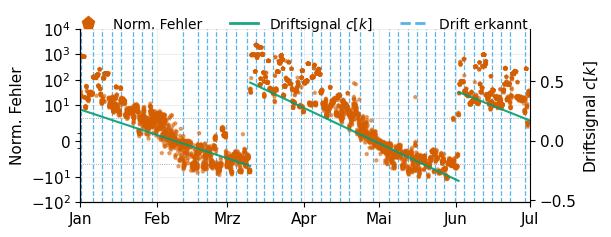

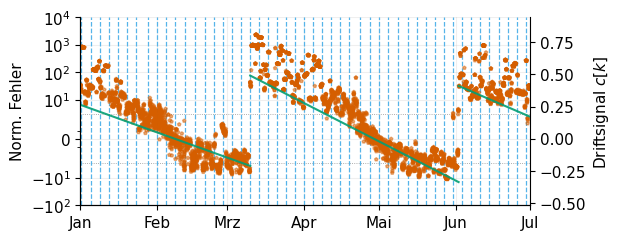

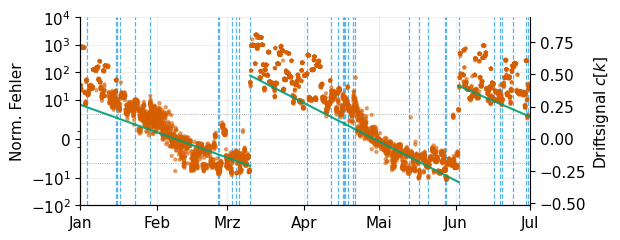

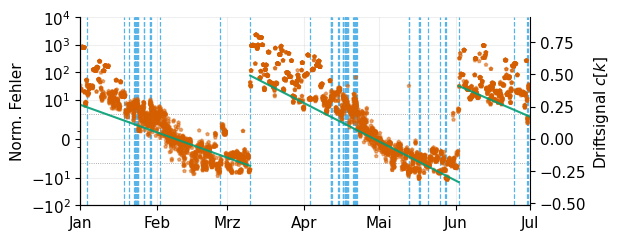

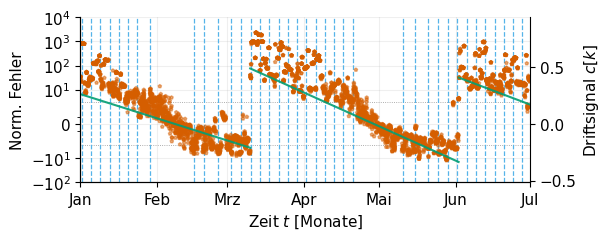

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from src.utils import thesis_style as ts

PLOT_END = pd.Timestamp("1970-07-01")
pdat = test_data.loc[:PLOT_END]
n_plot = len(pdat)
err_vals = np.nan_to_num(pdat["pred_error_norm_cd"].values)
rng_plot = np.random.default_rng(SEED)

detections = {"KSWIN": plot_thinned["KSWIN"][0], "ADWIN": plot_thinned["ADWIN"][0],
              "DDM": tuned["DDM"][0], "EDDM": tuned["EDDM"][0], "RMSE": plot_thinned["RMSE"][0]}

for j, (name, drifts) in enumerate(detections.items()):
    fig, ax, ax2 = ts.error_timeseries(
        pdat.index,
        [(err_vals, "drift_afflicted", "Norm. Fehler")],
        cd=pdat["cd"].values,
        detections=[pdat.index[d] for d in drifts if d < n_plot],
        xlabel="Zeit $t$ [Monate]" if j == len(detections) - 1 else None,
        ylim=(-1e2, 1e4), frac=0.02, rng=rng_plot, height_scale=0.4,
        legend=dict(bbox_to_anchor=[0.49, 1.15], loc="upper center", ncols=3) if j == 0 else False,
    )
    fig.tight_layout()
    # Immer schreiben, auch aus dem Cache: sonst bleiben die stabilen .pgf auf
    # dem Stand eines frueheren Laufs stehen, waehrend JSON und TeX schon die
    # neue id tragen -- Abbildung und Kennzahl stammten dann aus verschiedenen
    # Laeufen. publish() legt die Archivkopie ohnehin nur an, wenn sie fehlt.
    plot_store.save_figure(fig, f"detection_{name.lower()}", det_run, final=IS_FINAL, savefig_kwargs={"dpi": 300}, archive_kwargs={"dpi": 300})
    plt.show()

## Ergebnisse speichern

In [10]:
from src.utils import results_export as rx

N = len(error_stream)

def _full_metrics(drifts):
    return dd.score_detections(drifts, sudden_idx, drift_active, tolerance=TOLERANCE,
                               n=N, weights=WEIGHTS, fa_decades=FA_DECADES)


def _chance(n_det):
    """Recall und Verzug, die eine blind mit dieser Rate feuernde Folge erreicht.

    Bezugsgroesse fuer die Interpretation: ein Detektor, der alle N/n_det
    Schritte meldet, trifft ein Ereignis mit 1 - exp(-n_det * tolerance / N),
    und sein mittlerer Verzug ist der halbe Detektionsabstand. Ohne diese
    Groesse liest sich ein Recall von 1,00 als perfekt, auch wenn er es nicht ist.
    """
    if not n_det:
        return {"recall": 0.0, "mean_delay": None}
    return {"recall": float(1.0 - np.exp(-n_det * TOLERANCE / N)),
            "mean_delay": float(N / (2 * n_det))}

detector_results = {}
for _name in ["KSWIN", "ADWIN", "DDM", "EDDM", "RMSE"]:
    _ua = studies[_name].best_trial.user_attrs
    _drifts = tuned[_name][0]
    _m = _full_metrics(_drifts)
    _entry = {
        "best_params": best_params[_name],
        "tuning_metrics": {_k: _ua.get(_k) for _k in
            ["recall", "precision", "fa_term", "mean_delay", "n_false",
             "n_false_stable", "fa_per_true", "n_sudden", "n_detected", "score"]},
        "tuning_score": studies[_name].best_value,
        "full_stream": {"n_detected": _m["n_detected"], "recall": _m["recall"],
                        "precision": _m["precision"], "fa_term": _m["fa_term"],
                        "mean_delay": _m["mean_delay"],
                        "n_false": _m["n_false"], "n_false_stable": _m["n_false_stable"]},
        "chance": _chance(_m["n_detected"]),
        "crosscheck": {"top_k": TOP_K,
                       "rank_tuning": crosscheck[_name]["chosen"]["rank_tuning"],
                       "candidates": crosscheck[_name]["candidates"]},
        "drift_indices": list(_drifts),
    }
    if _name in plot_thinned:
        _entry["plot_thinned"] = {"plot_cooldown": COOLDOWN,
                                  "n_shown": len(plot_thinned[_name][0])}
    detector_results[_name] = _entry

(rx.ResultDoc()
   .integer("n_samples", N)
   .integer("n_sudden_drifts", len(sudden_idx))
   .set("sudden_drift_indices", sudden_idx)
   .integer("n_active", np.sum(drift_active))
   .set("tolerance", TOLERANCE)
   .set("tolerance_rel", TOLERANCE_REL)
   .num("event_spacing", EVENT_SPACING, 1)
   .set("plot_cooldown", COOLDOWN)
   .set("cooldown_rel", COOLDOWN_REL)
   .set("tuning", {"n_trials": N_TRIALS, "downsample": DOWNSAMPLE,
                   "weights": list(WEIGHTS), "fa_decades": FA_DECADES,
                   "top_k": TOP_K})
   .set("detectors", detector_results)
   .save(res_store, "detection", det_run, final=IS_FINAL))

Umfassende Ergebnisse -> C:\git\process_optimization_concept_drift\results\syn_detection.json


'C:\\git\\process_optimization_concept_drift\\results\\syn_detection.json'

In [11]:
from src.utils import latex_export as lx

mx = lx.MacroExport("Automatisch erzeugt aus syn_detection.ipynb - nicht manuell editieren")

_STEP_H = (test_data.index[1] - test_data.index[0]).total_seconds() / 3600

mx.comment("Parameter (Hash-relevant)")
mx.param("paramNTol", TOLERANCE)   # Toleranzfenster n_tol [Abtastschritte]
mx.num("paramNTolPct", 100 * TOLERANCE / EVENT_SPACING, 2)   # in % des Ereignisabstands
mx.num("paramNTolH", TOLERANCE * _STEP_H, 1)
mx.integer("paramRefract", COOLDOWN)
mx.num("paramRefractH", COOLDOWN * _STEP_H, 0)
mx.num("paramWRecall", WEIGHTS[0], 1)      # omega_rho
mx.num("paramWDelay", WEIGHTS[1], 1)       # omega_d
mx.num("paramWFa", WEIGHTS[2], 1)          # omega_fa
mx.num("paramFaDecades", FA_DECADES, 0)    # D im Fehlalarm-Term
mx.integer("paramDownsample", DOWNSAMPLE)  # Ausduennung waehrend des Tunings
mx.integer("paramTopK", TOP_K)             # gegengeprueft auf dem vollen Strom

mx.comment("Ergebnisse (Detektionskennzahlen je Detektor)")
for _name in ["KSWIN", "ADWIN", "DDM", "EDDM", "RMSE"]:
    _e = detector_results[_name]; _fs = _e["full_stream"]
    mx.num(f"drift{_name}Recall", _fs["recall"], 2)
    mx.num(f"drift{_name}Precision", _fs["precision"], 2)
    mx.num(f"drift{_name}Chance", _e["chance"]["recall"], 2)   # Recall bei blindem Feuern
    mx.num(f"drift{_name}Delay",  _fs["mean_delay"], 0)
    mx.num(f"drift{_name}DelayH", _fs["mean_delay"] * _STEP_H, 1)
    mx.integer(f"drift{_name}False",  _fs["n_false"])
    mx.integer(f"drift{_name}Drifts", _fs["n_detected"])
    if "plot_thinned" in _e:
        mx.integer(f"drift{_name}DriftsPlot", _e["plot_thinned"]["n_shown"])

mx.save(res_store, "detection", det_run, final=IS_FINAL)

LaTeX-Makros -> C:\git\process_optimization_concept_drift\results\syn_detection.tex

% Automatisch erzeugt aus syn_detection.ipynb - nicht manuell editieren

% Parameter (Hash-relevant)
\newcommand{\paramNTol}{1000}
\newcommand{\paramNTolPct}{0{,}92}
\newcommand{\paramNTolH}{16{,}7}
\newcommand{\paramRefract}{5000}
\newcommand{\paramRefractH}{83}
\newcommand{\paramWRecall}{3{,}0}
\newcommand{\paramWDelay}{0{,}3}
\newcommand{\paramWFa}{1{,}5}
\newcommand{\paramFaDecades}{3}
\newcommand{\paramDownsample}{5}
\newcommand{\paramTopK}{5}

% Ergebnisse (Detektionskennzahlen je Detektor)
\newcommand{\driftKSWINRecall}{1{,}00}
\newcommand{\driftKSWINPrecision}{0{,}02}
\newcommand{\driftKSWINChance}{0{,}70}
\newcommand{\driftKSWINDelay}{153}
\newcommand{\driftKSWINDelayH}{2{,}5}
\newcommand{\driftKSWINFalse}{614}
\newcommand{\driftKSWINDrifts}{626}
\newcommand{\driftKSWINDriftsPlot}{86}
\newcommand{\driftADWINRecall}{1{,}00}
\newcommand{\driftADWINPrecision}{0{,}01}
\newcommand{\driftADWINChance

'C:\\git\\process_optimization_concept_drift\\results\\syn_detection.tex'